In [10]:
from langgraph.graph import StateGraph, START, END,MessagesState
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
#importing trimming modules from langchain_core
from langchain_core.messages.utils import trim_messages, count_tokens_approximately
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
load_dotenv()

True

In [5]:
model = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

In [6]:
#We need maximum tokens 
MAX_TOKENS = 150

In [8]:
#defining node of a graph
def call_model(state:MessagesState):
    #trim message conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens= MAX_TOKENS
    )
    print("Current Token Count -> ",count_tokens_approximately(messages=messages))
    for msg in messages:
        print(msg.content)
    response = model.invoke(messages)
    return {"messages":[response]}

In [9]:
builder = StateGraph(MessagesState)
builder.add_node('call_model',call_model)
builder.add_edge(START,'call_model')

In [11]:
#adding a checkpointer before we compile the graph
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

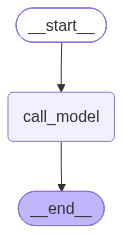

In [12]:
graph

In [13]:
config = {"configurable": {"thread_id": "chat-1"}}
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Nazia."}]},
    config,
)
result["messages"][-1].content

Current Token Count ->  10
Hi, my name is Nazia.


"Hi Nazia! It's nice to meet you.\n\nHow can I help you today?"

In [14]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count ->  40
Hi, my name is Nazia.
Hi Nazia! It's nice to meet you.

How can I help you today?
I am learning LangGraph.


"That's excellent, Nazia! LangGraph is a powerful library for building robust and stateful multi-actor applications with LLMs.\n\nI can definitely help you with your LangGraph journey. To get started, what specifically are you interested in or working on right now? For example:\n\n*   Are you looking for an introduction to the core concepts (nodes, edges, state, graphs)?\n*   Do you need help with a specific example or use case?\n*   Are you encountering any challenges with a particular feature?\n*   Do you want to discuss design patterns or best practices?\n*   Or perhaps you just want to brainstorm some ideas?\n\nLet me know how I can assist you!"

In [15]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count ->  13
Can you explain short term memory?


'Short-term memory (STM) is a temporary storage system that holds a limited amount of information for a brief period, allowing us to actively process and manipulate it. It\'s often likened to a "mental scratchpad" or a "workbench" where you keep the tools and materials you\'re actively using right now.\n\nHere\'s a breakdown of its key characteristics and functions:\n\n1.  **Limited Capacity:**\n    *   One of the most famous findings in psychology regarding STM is George A. Miller\'s "Magical Number Seven, Plus or Minus Two." This suggests that most people can hold roughly **5 to 9 discrete pieces of information** (or "chunks") in their STM at any given time.\n    *   **Chunking** is a crucial strategy to increase this apparent capacity. By grouping individual pieces of information into larger, meaningful units (e.g., remembering "FBI" as one chunk instead of three letters), we can effectively store more.\n\n2.  **Limited Duration:**\n    *   Information in STM is typically held for a

In [16]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count ->  8
What is my name?


"As an AI, I don't have access to personal information about you, including your name. I only know what you tell me during our conversation."

In [17]:
graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']

[HumanMessage(content='Hi, my name is Nazia.', additional_kwargs={}, response_metadata={}, id='68a8c02a-23cc-4d5b-849b-e28c669d9b57'),
 AIMessage(content="Hi Nazia! It's nice to meet you.\n\nHow can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f7931-06dc-7583-8601-2d662329cd89-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 495, 'total_tokens': 504, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 475}}),
 HumanMessage(content='I am learning LangGraph.', additional_kwargs={}, response_metadata={}, id='8a1697fe-4325-406d-815b-1789f70b9902'),
 AIMessage(content="That's excellent, Nazia! LangGraph is a powerful library for building robust and stateful multi-actor applications with LLMs.\n\nI can definitely help you with your LangGraph journey. To get started, what spec

In [18]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Nazia.
------------------------------------------------------------------------------------------------------------------------
Hi Nazia! It's nice to meet you.

How can I help you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That's excellent, Nazia! LangGraph is a powerful library for building robust and stateful multi-actor applications with LLMs.

I can definitely help you with your LangGraph journey. To get started, what specifically are you interested in or working on right now? For example:

*   Are you looking for an introduction to the core concepts (nodes, edges, state, graphs)?
*   Do you need help with a specific example or use case?
*   Are you encountering any challenges with a particular feature?
*   Do you want to discuss design pa